In [ ]:
import json
import uuid
from pathlib import Path
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
import numpy as np
from nltk.stem import SnowballStemmer,WordNetLemmatizer
_STOP_WORDS: frozenset[str] = frozenset(stopwords.words("spanish"))
stemmer =SnowballStemmer(language="spanish")
lem = WordNetLemmatizer()

In [185]:
path = Path('/Users/alberto/Desktop/SRI/data')
CATEGORIES = ("mobile", "pc")

In [186]:
def load_all(CATEGORIES):
    de =[]
    for cat in CATEGORIES:
        lis_doc = load(path,cat)
        de.extend(lis_doc)
    return de
def load_file(file_path,category):
    d=[]
    with open(file_path, "r", encoding="utf-8") as fh:
            for line_no, line in enumerate(fh, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    raw = json.loads(line)
                except json.JSONDecodeError as exc:
                    
                    continue

                doc = _normalise(raw, category=category)
                d.append(doc)
    return d
def load(path,cat):
    d=[]
    path1 = path/ cat
    for jsonl_file in sorted(path1.glob("*.jsonl")):
        list_doc = load_file(jsonl_file, category=cat)
        d.extend(list_doc)
    return d

def _normalise(raw: dict, category: str) -> dict:
        """
        Convert a raw Scrapy item dict into a canonical document dict.

        Canonical schema
        ----------------
        id          str   unique identifier (URL preferred)
        url         str
        title       str
        content     str
        author      str | None
        date        str | None   ISO-8601
        scraped_at  str | None   ISO-8601
        source      str
        tags        list[str]
        category    str          "mobile" | "pc" | "general"
        """
        url = raw.get("url", "")
        doc_id = (
            url
            if url
            else str(uuid.uuid5(uuid.NAMESPACE_URL, json.dumps(raw, sort_keys=True)))
        )

        return {
            "id": doc_id,
            "url": url,
            "title": raw.get("title") or "",
            "content": raw.get("content") or "",
            "author": raw.get("author"),
            "date": raw.get("date"),
            "scraped_at": raw.get("scraped_at"),
            "source": raw.get("source", ""),
            "tags": raw.get("tags") or [""],
            "category": category,
        }


In [187]:
docs = load_all(CATEGORIES)

In [188]:
len(docs)

4508

In [189]:
docs = [x for x in docs if len(x.get("content",""))>0]

In [190]:
len([x for x in docs if x.get("category")=="mobile"])

2718

In [191]:
len([x for x in docs if x.get("category")=="pc"])

1779

In [192]:
def analize(with_norm=False):
    len_char=[]
    len_word=[]
    t=Counter()
    indiv=[]
    for doc in docs:

        content = doc['content'].lower().replace("("," ").replace(")"," ").replace("|"," ").replace("`"," ").replace(":"," ").replace(", "," ").replace("''"," ").replace("."," ").strip()
        
        len_char.append(len(content))
        words = [x for x in word_tokenize(content) if x not in _STOP_WORDS]
        if with_norm:
            words = [stemmer.stem(x) for x in words]
        indiv.append(len(Counter(words)))
        
        t.update(words)
        len_word.append(len(words))
    return len_char,len_word,t,indiv
    

In [193]:
len_char,len_word,t,indiv =analize(with_norm=True)
len_char1,len_word1,t1,indiv1 =analize(with_norm=False)

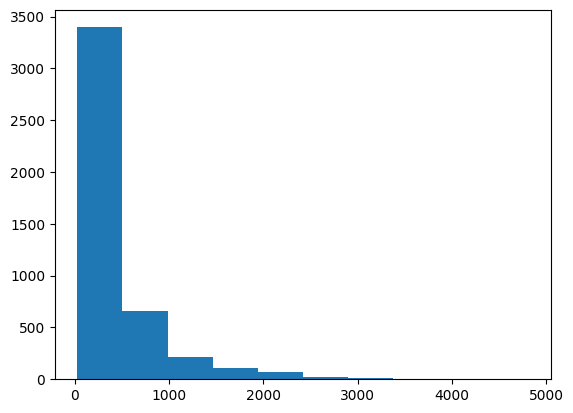

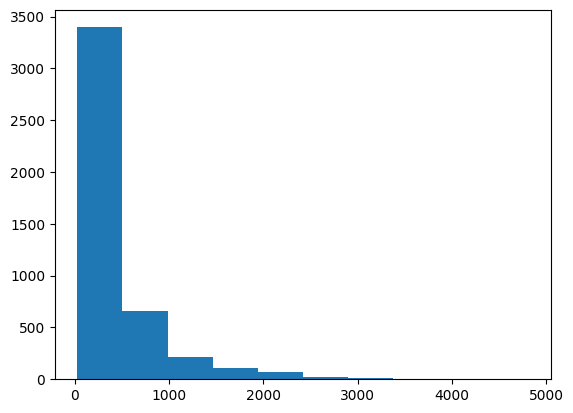

In [194]:
plt.hist(len_word)
plt.show()
plt.hist(len_word1)
plt.show()

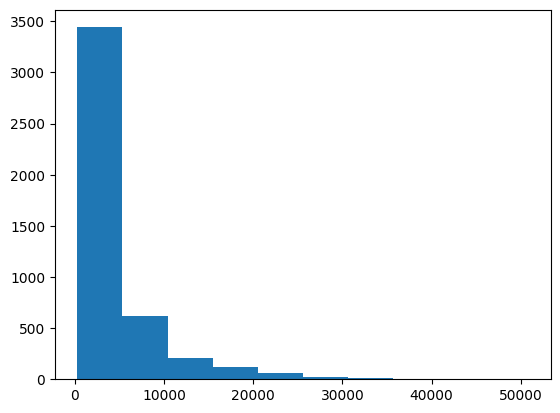

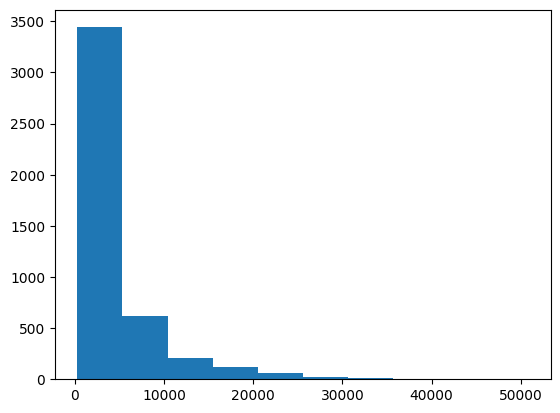

In [195]:
plt.hist(len_char)
plt.show()
plt.hist(len_char1)
plt.show()

In [196]:
len(t)

40095

In [197]:
len(t1)

69965

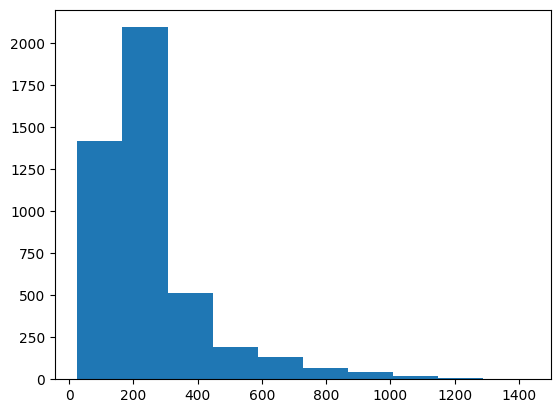

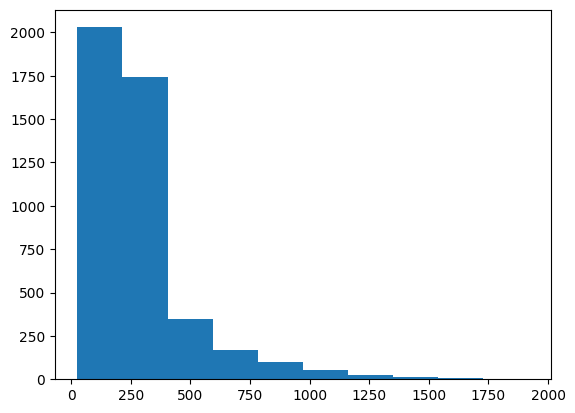

In [198]:
plt.hist(indiv)
plt.show()
plt.hist(indiv1)
plt.show()

In [199]:
max(indiv)

1429

In [200]:
max(indiv1)

1917

In [201]:
np.median(indiv)

np.float64(209.0)

In [202]:
np.median(indiv1)

np.float64(228.0)

In [203]:
np.mean(indiv)

np.float64(255.05892817433846)

In [204]:
np.mean(indiv1)

np.float64(290.20191238603513)

In [205]:
t.most_common(35)

[('pued', 14020),
 ('si', 12365),
 ('hac', 12049),
 ('pantall', 11736),
 ('movil', 11359),
 ('mejor', 9140),
 ('cam', 9086),
 ('nuev', 9060),
 ('2', 8018),
 ('gb', 7866),
 ('preci', 7576),
 ('pro', 7562),
 ('1', 7527),
 ('eur', 7352),
 ("''", 7256),
 ('sistem', 7156),
 ('sol', 6728),
 ('proces', 6605),
 ('pod', 6526),
 ('``', 6443),
 ('disposit', 6190),
 ('aunqu', 6106),
 ('aplic', 6048),
 ('part', 5997),
 ('pas', 5969),
 ('fabric', 5937),
 ('lleg', 5795),
 ('andro', 5724),
 ('xatak', 5656),
 ('model', 5599),
 ('apple', 5505),
 ('funcion', 5498),
 ('carg', 5385),
 ('opcion', 5296),
 ('dos', 5273)]

In [206]:
t1.most_common(35)

[('si', 12365),
 ('pantalla', 10829),
 ('2', 8018),
 ('gb', 7866),
 ('pro', 7561),
 ('1', 7527),
 ('euros', 7330),
 ("''", 7256),
 ('móvil', 7184),
 ('cámara', 6805),
 ('``', 6443),
 ('precio', 6217),
 ('aunque', 6106),
 ('sistema', 6099),
 ('android', 5722),
 ('xataka', 5656),
 ('apple', 5505),
 ('dos', 5273),
 ('puede', 5237),
 ('ser', 5175),
 ('x', 5170),
 ('5', 5108),
 ('8', 4926),
 ('3', 4903),
 ('google', 4882),
 ('samsung', 4842),
 ('ahora', 4818),
 ('batería', 4769),
 ('además', 4594),
 ('hace', 4559),
 ('así', 4495),
 ('windows', 4445),
 ('solo', 4377),
 ('%', 4370),
 ('carga', 4287)]